# 🚀 Fashion RAG - Enhanced Version + FashionCLIP 2.0
## Multi-modal Hybrid Retrieval with Advanced Features

### ✨ Improvements:
- ✅ Query Expansion for better recall
- ✅ Dynamic BM25 weighting
- ✅ Deduplication logic
- ✅ Soft relevance scoring
- ✅ Fallback strategies
- ✅ Cross-Encoder reranking
- ✅ User feedback mechanism
- ✅ **FashionCLIP 2.0** (`patrickjohncyh/fashion-clip`) — Recall@1 tăng ~40% vs CLIP ViT-B/32

### 🔄 Thay đổi so với phiên bản trước:
| Thành phần | Cũ | Mới |
|---|---|---|
| Embedding model | OpenAI CLIP ViT-B/32 | FashionCLIP 2.0 (patrickjohncyh/fashion-clip) |
| Install | `git+https://github.com/openai/CLIP.git` (hay bị lỗi) | `transformers` (ổn định) |
| Import | `from llama_index.embeddings.clip import ClipEmbedding` | `FashionCLIPEmbedding` (custom class) |
| Collection name | `clip_fashion_collection` | `fashionclip2_collection` |
| Embedding dim | 512 | 512 (tương thích) |
| Training data | 400M general images | 800K Farfetch fashion products |


## 📦 Installation

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 1. Cài đặt các thư viện nền tảng và Deep Learning
!pip install -q torch torchvision
!pip install -q ftfy regex tqdm

# 2. FashionCLIP 2.0 dùng HuggingFace Transformers — KHÔNG cần git+CLIP
# patrickjohncyh/fashion-clip là ViT-B/32 fine-tuned trên 800K sản phẩm Farfetch
!pip install -q transformers accelerate

print('✅ Base packages installed (torch + transformers)')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.2 MB/s eta 0:00:00
✅ Base packages installed (torch + transformers)


In [3]:
# 3. Cài đặt LlamaIndex Core và các thành phần xử lý dữ liệu
!pip install -q llama-index-core
!pip install -q pandas matplotlib scikit-image pillow rapidfuzz

# 4. Cài đặt các Extension của LlamaIndex
# NOTE: llama-index-embeddings-clip đã bị LOẠI BỎ — dùng FashionCLIPEmbedding custom thay thế
!pip install -q llama-index-vector-stores-qdrant qdrant_client
!pip install -q llama-index-llms-google-genai google-generativeai
!pip install -q llama-index-retrievers-bm25 rank_bm25
!pip install -q sentence-transformers

# 5. Giao diện
!pip install -q gradio

print('✅ Tất cả các gói đã được cài đặt — FashionCLIP 2.0 ready!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 5.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.4/390.4 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 683.3/683.3 kB 55.6 MB/s eta 0:00:00
✅ Tất cả các gói đã được cài đặt — FashionCLIP 2.0 rea

In [4]:
# Verify FashionCLIP 2.0 có thể load được từ HuggingFace
from transformers import CLIPProcessor, CLIPModel
import torch

print('⬇️  Downloading FashionCLIP 2.0 model (patrickjohncyh/fashion-clip)...')
print('   First run: ~1.7 GB download. Subsequent runs: cached locally.')

_test_model = CLIPModel.from_pretrained('patrickjohncyh/fashion-clip')
_test_proc  = CLIPProcessor.from_pretrained('patrickjohncyh/fashion-clip')

del _test_model, _test_proc  # giải phóng RAM, sẽ load lại trong class
print('✅ FashionCLIP 2.0 verified successfully!')
print(f'   Device available: {"CUDA" if torch.cuda.is_available() else "CPU"}')

⬇️  Downloading FashionCLIP 2.0 model (patrickjohncyh/fashion-clip)...
   First run: ~1.7 GB download. Subsequent runs: cached locally.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

✅ FashionCLIP 2.0 verified successfully!
   Device available: CUDA


In [5]:
!pip freeze > requirements.txt

## 📚 Import Libraries

In [6]:
# Core Libraries
import os
import shutil
import json
import re
import asyncio
from pathlib import Path
from typing import List, Dict, Tuple, Optional
from collections import defaultdict

# Data Processing
import pandas as pd
from tqdm import tqdm
import numpy as np

# LlamaIndex
from llama_index.core import Document, StorageContext
from llama_index.core.indices.multi_modal import MultiModalVectorStoreIndex
from llama_index.core.schema import ImageDocument, ImageNode, TextNode, NodeWithScore, QueryBundle, MetadataMode
from llama_index.core.retrievers import BaseRetriever
from llama_index.core.query_engine import RetrieverQueryEngine
from llama_index.core import get_response_synthesizer
from llama_index.core.embeddings import MultiModalEmbedding  # Base class cho custom embedding
from llama_index.vector_stores.qdrant import QdrantVectorStore
# NOTE: ClipEmbedding đã bị XOÁ — thay bằng FashionCLIPEmbedding (cell tiếp theo)
from llama_index.retrievers.bm25 import BM25Retriever
from llama_index.llms.google_genai import GoogleGenAI

# FashionCLIP 2.0 — HuggingFace Transformers
import torch
from transformers import CLIPModel, CLIPProcessor
from PIL import Image

# Visualization
import matplotlib.pyplot as plt

# Vector DB
import qdrant_client

# Reranking
from sentence_transformers import CrossEncoder

# Fuzzy Matching
from rapidfuzz import fuzz

print('✅ All imports successful!')

✅ All imports successful!


In [7]:
class FashionCLIPEmbedding(MultiModalEmbedding):
    MODEL_ID: str = 'patrickjohncyh/fashion-clip'

    def __init__(self, model_name: str = 'patrickjohncyh/fashion-clip',
                 embed_batch_size: int = 32, **kwargs):
        super().__init__(embed_batch_size=embed_batch_size, model_name=model_name, **kwargs)
        self._device = 'cuda' if torch.cuda.is_available() else 'cpu'
        print(f'  🎨 Loading FashionCLIP 2.0 on {self._device}...')
        self._model = CLIPModel.from_pretrained(model_name).to(self._device)
        self._processor = CLIPProcessor.from_pretrained(model_name)
        self._model.eval()
        print(f'  ✅ FashionCLIP 2.0 loaded! Embedding dim: 512')

    def _ensure_tensor(self, outputs):
        """Đảm bảo trả về Tensor thay vì HuggingFace Object"""
        if hasattr(outputs, 'pooler_output'):
            return outputs.pooler_output
        return outputs

    def _get_text_embedding(self, text: str) -> List[float]:
        inputs = self._processor(text=[text], return_tensors='pt', padding=True, truncation=True, max_length=77).to(self._device)
        with torch.no_grad():
            outputs = self._model.get_text_features(**inputs)
            features = self._ensure_tensor(outputs)
            features = features / features.norm(dim=-1, keepdim=True)
        return features[0].cpu().tolist()

    def _get_text_embeddings(self, texts: List[str]) -> List[List[float]]:
        all_embeddings = []
        for i in range(0, len(texts), self.embed_batch_size):
            batch = texts[i : i + self.embed_batch_size]
            inputs = self._processor(text=batch, return_tensors='pt', padding=True, truncation=True, max_length=77).to(self._device)
            with torch.no_grad():
                outputs = self._model.get_text_features(**inputs)
                features = self._ensure_tensor(outputs)
                features = features / features.norm(dim=-1, keepdim=True)
            all_embeddings.extend(features.cpu().tolist())
        return all_embeddings

    def _get_image_embedding(self, img_file_path: str) -> List[float]:
        try:
            image = Image.open(img_file_path).convert('RGB')
        except Exception as e:
            print(f'  ⚠️ Cannot open image {img_file_path}: {e}')
            return [0.0] * 512
        inputs = self._processor(images=image, return_tensors='pt').to(self._device)
        with torch.no_grad():
            outputs = self._model.get_image_features(**inputs)
            features = self._ensure_tensor(outputs)
            features = features / features.norm(dim=-1, keepdim=True)
        return features[0].cpu().tolist()

    def _get_image_embeddings(self, img_file_paths: List[str]) -> List[List[float]]:
        all_embeddings = []
        for i in range(0, len(img_file_paths), self.embed_batch_size):
            batch_paths = img_file_paths[i : i + self.embed_batch_size]
            images = []
            for p in batch_paths:
                try:
                    images.append(Image.open(p).convert('RGB'))
                except:
                    images.append(Image.new('RGB', (224, 224)))
            inputs = self._processor(images=images, return_tensors='pt').to(self._device)
            with torch.no_grad():
                outputs = self._model.get_image_features(**inputs)
                features = self._ensure_tensor(outputs)
                features = features / features.norm(dim=-1, keepdim=True)
            all_embeddings.extend(features.cpu().tolist())
        return all_embeddings

    def _get_query_embedding(self, query: str) -> List[float]:
        return self._get_text_embedding(query)

    async def _aget_text_embedding(self, text: str) -> List[float]:
        return self._get_text_embedding(text)

    async def _aget_image_embedding(self, img_file_path: str) -> List[float]:
        return self._get_image_embedding(img_file_path)

    async def _aget_query_embedding(self, query: str) -> List[float]:
        return self._get_query_embedding(query)

## ⚙️ Configuration

In [8]:
import getpass

# Setup paths
BASE_PATH = "/content/drive/MyDrive/RAG-practice/my_fashion_data"
CSV_PATH = os.path.join(BASE_PATH, "images.csv")
IMAGES_PATH = os.path.join(BASE_PATH, "images_compressed")

print(f"📁 Data paths:")
print(f"  CSV: {CSV_PATH}")
print(f"  Images: {IMAGES_PATH}")

# Setup Gemini API
gemini_api_key_raw = getpass.getpass("Enter your Google Gemini API Key: ")
gemini_api_key = gemini_api_key_raw.strip().encode('ascii', 'ignore').decode('ascii')
os.environ["GOOGLE_API_KEY"] = gemini_api_key

print("✓ API configured!")

📁 Data paths:
  CSV: /content/drive/MyDrive/RAG-practice/my_fashion_data/images.csv
  Images: /content/drive/MyDrive/RAG-practice/my_fashion_data/images_compressed
Enter your Google Gemini API Key: ··········
✓ API configured!


## 📊 Load Dataset

In [9]:
print("\n" + "="*70)
print("LOADING DATASET")
print("="*70)

df = pd.read_csv(CSV_PATH)
print(f"\n📊 Dataset Overview:")
print(f"   Total rows: {len(df)}")
print(f"   Columns: {df.columns.tolist()}")

print(f"\n📋 First 5 rows:")
print(df.head())

print(f"\n📈 Label distribution:")
print(df['label'].value_counts())


LOADING DATASET

📊 Dataset Overview:
   Total rows: 5096
   Columns: ['image', 'label', 'caption', 'color']

📋 First 5 rows:
                                  image    label  \
0  ea7b6656-3f84-4eb3-9099-23e623fc1018  T-Shirt   
1  ea2ffd4d-9b25-4ca8-9dc2-bd27f1cc59fa  T-Shirt   
2  3b86d877-2b9e-4c8b-a6a2-1d87513309d0    Shoes   
3  5d3a1404-697f-479f-9090-c1ecd0413d27   Shorts   
4  b0c03127-9dfb-4573-8934-1958396937bf    Shirt   

                                             caption  \
0  Crafted from a smooth jersey knit, this fitted...   
1  A short-sleeved knit top crafted from a mottle...   
2  Supple leather ankle boots feature a pointed t...   
3  Crafted from a lightweight woven textile featu...   
4  An oversized silhouette in a brushed woven tex...   

                          color  
0                      Burgundy  
1      Charcoal Grey Camouflage  
2  Black with Silver embroidery  
3    Navy Blue abstract pattern  
4           Red and Black Plaid  

📈 Label distributio

## 🔧 Utility Functions

In [10]:
def find_image_path(image_id: str, image_dir: str) -> Optional[str]:
    """Tìm đường dẫn ảnh với các extension khác nhau"""
    image_dir = Path(image_dir)
    for ext in [".jpg", ".jpeg", ".png", ".webp"]:
        p = image_dir / f"{image_id}{ext}"
        if p.exists():
            return str(p)
    return None


def calculate_color_similarity(color1: str, color2: str) -> float:
    """Tính độ tương đồng giữa 2 màu sắc bằng fuzzy matching"""
    if not color1 or not color2:
        return 0.0

    # Normalize
    c1 = color1.lower().strip()
    c2 = color2.lower().strip()

    # Exact match
    if c1 == c2:
        return 1.0

    # Partial match ("navy blue" contains "blue")
    if c1 in c2 or c2 in c1:
        return 0.8

    # Fuzzy match
    ratio = fuzz.ratio(c1, c2) / 100.0
    return ratio


def calculate_category_similarity(cat1: str, cat2: str) -> float:
    """Tính độ tương đồng giữa 2 categories"""
    if not cat1 or not cat2:
        return 0.0

    c1 = cat1.lower().strip()
    c2 = cat2.lower().strip()

    if c1 == c2:
        return 1.0

    if c1 in c2 or c2 in c1:
        return 0.9

    ratio = fuzz.ratio(c1, c2) / 100.0
    return ratio


print("✅ Utility functions loaded")

✅ Utility functions loaded


## 📄 Document Preparation

In [11]:
def prepare_documents(csv_path: str, img_dir: str, max_items: int = 1000):
    """Chuẩn bị documents với metadata được optimize"""
    df = pd.read_csv(csv_path).head(max_items).fillna("")
    text_docs, image_docs = [], []

    print(f"🔄 Processing {len(df)} items...")

    for _, row in tqdm(df.iterrows(), total=len(df)):
        image_id = str(row["image"])
        full_caption = str(row["caption"])
        label = str(row["label"])
        color = str(row["color"])

        image_path = find_image_path(image_id, img_dir)
        if image_path is None:
            continue

        # BM25 content (keywords)
        bm25_content = f"{label}. {color}."

        text_meta = {
            "image_id": image_id,
            "image_path": image_path,
            "category": label,
            "color": color,
            "full_description": full_caption
        }

        # Text Document
        text_doc = Document(text=bm25_content, metadata=text_meta)

        # Exclude noise from embeddings
        text_doc.excluded_embed_metadata_keys = ["image_id", "image_path", "category", "color"]
        text_doc.excluded_llm_metadata_keys = ["image_id", "image_path"]

        # Format: Content first, metadata later
        text_doc.text_template = "{content}\n\n{metadata_str}"
        text_doc.metadata_template = "{value}"
        text_doc.metadata_separator = " "

        text_docs.append(text_doc)

        # Image Document
        image_doc = ImageDocument(image_path=image_path, metadata=text_meta)
        image_doc.excluded_embed_metadata_keys = ["image_id", "category", "color", "full_description"]
        image_docs.append(image_doc)

    return text_docs, image_docs


# Create documents
text_documents, image_documents = prepare_documents(CSV_PATH, IMAGES_PATH, max_items=2000)

print(f"\n✅ Created {len(text_documents)} text nodes and {len(image_documents)} image nodes.")

🔄 Processing 2000 items...


100%|██████████| 2000/2000 [23:09<00:00,  1.44it/s]


✅ Created 2000 text nodes and 2000 image nodes.


## 🔍 Verify Documents

In [12]:
if len(text_documents) > 0:
    test_node = text_documents[0]

    print("🔍 BM25 sẽ tìm trên (Keywords):")
    print(f"'{test_node.get_content(metadata_mode=MetadataMode.NONE)}'")

    print("\n🧠 CLIP Embedding sẽ hiểu (Context):")
    print(f"'{test_node.get_content(metadata_mode=MetadataMode.EMBED)}'")

    print("\n💬 Gemini LLM sẽ dùng để trả lời (Full Info):")
    print(f"'{test_node.get_content(metadata_mode=MetadataMode.LLM)}'")

🔍 BM25 sẽ tìm trên (Keywords):
'T-Shirt. Burgundy.'

🧠 CLIP Embedding sẽ hiểu (Context):
'T-Shirt. Burgundy.

Crafted from a smooth jersey knit, this fitted top features a classic crew neck and short sleeves. Three polished snaps embellish a subtle placket on one shoulder. Its clean lines and tailored silhouette project a versatile, refined casual aesthetic.'

💬 Gemini LLM sẽ dùng để trả lời (Full Info):
'T-Shirt. Burgundy.

T-Shirt Burgundy Crafted from a smooth jersey knit, this fitted top features a classic crew neck and short sleeves. Three polished snaps embellish a subtle placket on one shoulder. Its clean lines and tailored silhouette project a versatile, refined casual aesthetic.'


## 🧹 Clean Previous Database

In [13]:
if os.path.exists("./qdrant_db"):
    shutil.rmtree("./qdrant_db")
    print("🧹 Đã xóa DB cũ và giải phóng lock!")

## 🎨 Build FashionCLIP 2.0 Index
> **Thay thế**: `build_clip_index()` (OpenAI CLIP ViT-B/32) → `build_fashion_clip_index()` (FashionCLIP 2.0)


In [14]:
import os
import shutil
import qdrant_client
from llama_index.core import StorageContext
from llama_index.core.indices.multi_modal import MultiModalVectorStoreIndex
from llama_index.vector_stores.qdrant import QdrantVectorStore

def build_fashion_clip_index(text_docs, image_docs, persist_dir='./storage_fashion'):
    print('🎨 Initializing FashionCLIP 2.0 Embedding...')
    fashion_embed = FashionCLIPEmbedding(
        model_name='patrickjohncyh/fashion-clip',
        embed_batch_size=32
    )

    print('\n💾 Initializing Local Qdrant Client...')
    db_path = './qdrant_db_new' # Đổi tên thư mục DB mới

    # Tự động dọn dẹp DB cũ nếu có để tránh lỗi Lock
    if os.path.exists(db_path):
        shutil.rmtree(db_path)
        print(f"   🧹 Đã dọn dẹp thư mục {db_path} cũ để tránh lỗi Lock.")

    client = qdrant_client.QdrantClient(path=db_path)

    vector_store = QdrantVectorStore(
        client=client,
        collection_name='fashion_collection'
    )

    storage_context = StorageContext.from_defaults(vector_store=vector_store)

    print(f'\n🏗️ Building MultiModal Index từ {len(text_docs) + len(image_docs)} nodes...')

    index = MultiModalVectorStoreIndex.from_documents(
        documents=text_docs + image_docs,
        storage_context=storage_context,
        embed_model=fashion_embed,        # BẮT BUỘC: Model cho Text
        image_embed_model=fashion_embed,  # BẮT BUỘC: Model cho Ảnh (Fix lỗi import module)
        show_progress=True
    )

    index.storage_context.persist(persist_dir=persist_dir)
    print(f'\n✅ FashionCLIP 2.0 Index built successfully!')

    return index, fashion_embed

In [15]:

# Chạy tiến trình build (Chờ thanh Progress chạy 100%)
index, fashion_embed = build_fashion_clip_index(text_documents, image_documents)

🎨 Initializing FashionCLIP 2.0 Embedding...
  🎨 Loading FashionCLIP 2.0 on cuda...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ✅ FashionCLIP 2.0 loaded! Embedding dim: 512

💾 Initializing Local Qdrant Client...

🏗️ Building MultiModal Index từ 4000 nodes...


Applying transformations:   0%|          | 0/1 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/2000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/llama_index/vector_stores/qdrant/base.py:852: UserWarning: Payload indexes have no effect in the local Qdrant. Please use server Qdrant if you need payload indexes.
  self._client.create_payload_index(


Generating image embeddings:   0%|          | 0/2000 [00:00<?, ?it/s]


✅ FashionCLIP 2.0 Index built successfully!


## 🤖 Initialize LLM

In [16]:
import os
import getpass
from llama_index.llms.google_genai import GoogleGenAI

# 1. Nhập và làm sạch API Key an toàn
gemini_api_key_raw = getpass.getpass("Enter your Google Gemini API Key: ")
gemini_api_key = gemini_api_key_raw.strip().encode('ascii', 'ignore').decode('ascii')
os.environ["GOOGLE_API_KEY"] = gemini_api_key

print("✓ API configured!")

# 2. Khởi tạo LLM
llm = GoogleGenAI(
    model="models/gemini-2.5-pro",
    api_key=os.environ["GOOGLE_API_KEY"],  # CHÚ Ý: Sửa 'gemini_api_key' thành 'api_key'
    temperature=0.1,
)

print("✅ LLM Initialized: Gemini 2.5 pro")

Enter your Google Gemini API Key: ··········
✓ API configured!
✅ LLM Initialized: Gemini 2.5 pro


## 🎯 Advanced Helper Functions

In [31]:
# ==================== QUERY EXPANSION ====================
def expand_query(query: str, llm, max_expansions: int = 3) -> List[str]:
    """
    Mở rộng query với synonyms và related terms
    VD: "navy shirt" → ["navy shirt", "dark blue shirt", "blue formal shirt"]
    """
    prompt = f"""Generate {max_expansions} similar search queries for fashion items.
Each query should be a variation with synonyms or related terms.
Return ONLY a JSON array of strings, no explanation.

Original query: "{query}"

Example:
Original: "red dress"
Output: ["red dress", "crimson gown", "scarlet formal dress"]
"""

    try:
        response = llm.complete(prompt).text
        json_str = re.search(r'\[.*\]', response, re.DOTALL).group()
        expanded = json.loads(json_str)

        # Always include original query
        if query not in expanded:
            expanded.insert(0, query)

        return expanded[:max_expansions]
    except Exception as e:
        print(f"⚠️ Query expansion failed: {e}")
        return [query]


# ==================== FILTER EXTRACTION ====================
def extract_metadata_filters(query: str, llm) -> Dict[str, str]:
    """Trích xuất category/color từ query bằng LLM"""
    prompt = f"""Extract 'category' and 'color' from this fashion search query.
Return ONLY valid JSON format. If not found, use null.

Examples:
Query: "Find me a blue t-shirt" → {{"category": "T-Shirt", "color": "Blue"}}
Query: "red dress for party" → {{"category": "Dress", "color": "Red"}}
Query: "shoes" → {{"category": "Shoes", "color": null}}

Query: "{query}"
"""

    try:
        response = llm.complete(prompt).text
        json_str = re.search(r'\{.*\}', response, re.DOTALL).group()
        filters = json.loads(json_str)

        # Remove null values
        return {k: v for k, v in filters.items() if v is not None}
    except Exception as e:
        print(f"⚠️ Filter extraction failed: {e}")
        return {}


# ==================== RRF FUSION ====================
def rrf_fusion(
    bm25_nodes: List[NodeWithScore],
    vector_nodes: List[NodeWithScore],
    k: int = 60,
    bm25_weight: float = 2.5  # Giảm từ 5.0 xuống 2.5
) -> List[NodeWithScore]:
    """
    Reciprocal Rank Fusion với dynamic weighting
    bm25_weight = 2.5: Cân bằng hơn giữa keyword và semantic
    """
    fused_scores = {}

    # Vector scores
    for rank, node in enumerate(vector_nodes):
        if node.node_id not in fused_scores:
            fused_scores[node.node_id] = {"node": node, "score": 0.0}
        fused_scores[node.node_id]["score"] += 1.0 / (k + rank + 1)

    # BM25 scores (with weight)
    for rank, node in enumerate(bm25_nodes):
        if node.node_id not in fused_scores:
            fused_scores[node.node_id] = {"node": node, "score": 0.0}
        score = (1.0 / (k + rank + 1)) * bm25_weight
        fused_scores[node.node_id]["score"] += score

    # Sort by score
    sorted_nodes = sorted(
        fused_scores.values(),
        key=lambda x: x["score"],
        reverse=True
    )

    final_nodes = []
    for item in sorted_nodes:
        node = item["node"]
        node.score = item["score"]
        final_nodes.append(node)

    return final_nodes


# ==================== RELEVANCE SCORING ====================
def calculate_relevance_score(
    node: NodeWithScore,
    filters: Dict[str, str]
) -> float:
    """
    Tính soft relevance score thay vì hard filter
    Score từ 0.0 đến 1.0
    """
    if not filters:
        return 1.0

    actual_node = node.node if hasattr(node, 'node') else node
    meta = actual_node.metadata

    scores = []

    # Color similarity
    if "color" in filters:
        color_sim = calculate_color_similarity(
            filters["color"],
            meta.get("color", "")
        )
        scores.append(color_sim)

    # Category similarity
    if "category" in filters:
        cat_sim = calculate_category_similarity(
            filters["category"],
            meta.get("category", "")
        )
        scores.append(cat_sim)

    # Average score
    return sum(scores) / len(scores) if scores else 1.0


# ==================== DEDUPLICATION ====================
def deduplicate_nodes(nodes: List[NodeWithScore]) -> List[NodeWithScore]:
    """Loại bỏ duplicate nodes dựa trên image_id"""
    seen_ids = set()
    unique_nodes = []

    for node in nodes:
        actual_node = node.node if hasattr(node, 'node') else node
        img_id = actual_node.metadata.get("image_id")

        if img_id not in seen_ids:
            seen_ids.add(img_id)
            unique_nodes.append(node)

    return unique_nodes


print("✅ Advanced helper functions loaded")

✅ Advanced helper functions loaded


## 🚀 Enhanced Hybrid Retriever

In [32]:
class EnhancedFashionRetriever(BaseRetriever):
    """Enhanced retriever với query expansion, soft filtering, và reranking"""

    def __init__(
        self,
        vector_index,
        text_nodes,
        llm,
        top_k_text: int = 5,
        top_k_image: int = 5,
        enable_query_expansion: bool = True,
        enable_reranking: bool = True,
        relevance_threshold: float = 0.3
    ):
        super().__init__()
        self.llm = llm
        self.top_k_text = top_k_text
        self.top_k_image = top_k_image
        self.enable_query_expansion = enable_query_expansion
        self.enable_reranking = enable_reranking
        self.relevance_threshold = relevance_threshold

        # Retrievers (lấy dư để có nhiều candidates)
        self.vector_retriever = vector_index.as_retriever(
            similarity_top_k=top_k_image + 20
        )

        self.bm25_retriever = BM25Retriever.from_defaults(
            nodes=text_nodes,
            similarity_top_k=top_k_text + 20
        )

        # Cross-Encoder for reranking
        if enable_reranking:
            try:
                self.reranker = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')
                print("✅ Cross-Encoder reranker loaded")
            except:
                print("⚠️ Cross-Encoder not available, skipping reranking")
                self.enable_reranking = False

    def _soft_filter_and_score(
        self,
        nodes: List[NodeWithScore],
        filters: Dict[str, str]
    ) -> List[Tuple[NodeWithScore, float]]:
        """Soft filtering với relevance scoring"""
        scored_nodes = []

        for node in nodes:
            relevance = calculate_relevance_score(node, filters)

            # Chỉ giữ nodes có relevance > threshold
            if relevance >= self.relevance_threshold:
                scored_nodes.append((node, relevance))

        return scored_nodes

    def _rerank_nodes(
        self,
        query: str,
        nodes: List[NodeWithScore]
    ) -> List[NodeWithScore]:
        """Rerank nodes bằng Cross-Encoder"""
        if not self.enable_reranking or not nodes:
            return nodes

        try:
            # Prepare pairs
            pairs = []
            for node in nodes:
                actual_node = node.node if hasattr(node, 'node') else node

                if isinstance(actual_node, TextNode):
                    text = actual_node.get_content(metadata_mode=MetadataMode.LLM)
                else:
                    # For image nodes, use metadata description
                    text = actual_node.metadata.get("full_description", "")

                pairs.append([query, text])

            # Get reranking scores
            scores = self.reranker.predict(pairs)

            # Combine với original scores
            for i, node in enumerate(nodes):
                # Weighted combination: 70% rerank + 30% original
                node.score = 0.7 * float(scores[i]) + 0.3 * (node.score or 0.0)

            # Re-sort
            nodes = sorted(nodes, key=lambda x: x.score, reverse=True)

            print(f"  🔄 Reranked {len(nodes)} nodes")
        except Exception as e:
            print(f"  ⚠️ Reranking failed: {e}")

        return nodes

    def _retrieve_with_expansion(
        self,
        query: str
    ) -> Tuple[List[NodeWithScore], List[NodeWithScore]]:
        """Retrieve với query expansion"""
        if self.enable_query_expansion:
            expanded_queries = expand_query(query, self.llm, max_expansions=3)
            print(f"  🔍 Expanded to {len(expanded_queries)} queries: {expanded_queries}")
        else:
            expanded_queries = [query]

        all_vec_results = []
        all_bm25_results = []

        # Retrieve cho mỗi expanded query
        for q in expanded_queries:
            qb = QueryBundle(query_str=q)
            all_vec_results.extend(self.vector_retriever.retrieve(qb))
            all_bm25_results.extend(self.bm25_retriever.retrieve(qb))

        # Deduplicate
        all_vec_results = deduplicate_nodes(all_vec_results)
        all_bm25_results = deduplicate_nodes(all_bm25_results)

        return all_vec_results, all_bm25_results

    def _retrieve(self, query_bundle: QueryBundle) -> List[NodeWithScore]:
        query = query_bundle.query_str
        print(f"\n🎯 Processing query: '{query}'")

        # 1. Extract filters
        filters = extract_metadata_filters(query, self.llm)
        print(f"  📋 Extracted filters: {filters}")

        # 2. Retrieve với expansion
        vec_results, bm25_results = self._retrieve_with_expansion(query)
        print(f"  📊 Initial results: {len(vec_results)} vector, {len(bm25_results)} BM25")

        # 3. Phân loại Text/Image
        vec_text, vec_img = [], []
        for n in vec_results:
            actual_node = n.node if hasattr(n, 'node') else n
            if isinstance(actual_node, ImageNode):
                vec_img.append(n)
            else:
                vec_text.append(n)

        # 4. RRF Fusion cho text
        fused_text = rrf_fusion(bm25_results, vec_text, bm25_weight=2.5)

        # 5. Soft filtering với relevance scoring
        scored_text = self._soft_filter_and_score(fused_text, filters)
        scored_img = self._soft_filter_and_score(vec_img, filters)

        print(f"  ✅ After soft filter: {len(scored_text)} text, {len(scored_img)} images")

        # 6. Combine RRF score + Relevance score
        for node, rel_score in scored_text:
            node.score = (node.score or 0.0) * rel_score

        for node, rel_score in scored_img:
            node.score = (node.score or 0.0) * rel_score

        # Extract nodes
        text_nodes = [n for n, _ in scored_text]
        img_nodes = [n for n, _ in scored_img]

        # 7. Reranking
        text_nodes = self._rerank_nodes(query, text_nodes)
        img_nodes = self._rerank_nodes(query, img_nodes)

        # 8. Top-K selection
        final_results = text_nodes[:self.top_k_text] + img_nodes[:self.top_k_image]

        # 9. Final deduplication
        final_results = deduplicate_nodes(final_results)

        print(f"  🎉 Final: {len(final_results)} unique results")

        return final_results


print("✅ EnhancedFashionRetriever class loaded")

✅ EnhancedFashionRetriever class loaded


## ⚙️ Initialize Enhanced RAG Engine

In [33]:
print("⚙️ Setting up Enhanced RAG Engine...")

# fashion_embed được truyền vào để retriever dùng đúng embedding model
enhanced_retriever = EnhancedFashionRetriever(
    vector_index=index,
    text_nodes=text_documents,
    llm=llm,
    top_k_text=5,
    top_k_image=5,
    enable_query_expansion=True,
    enable_reranking=True,
    relevance_threshold=0.3  # Threshold cho soft filtering
)

synthesizer = get_response_synthesizer(llm=llm)

enhanced_engine = RetrieverQueryEngine(
    retriever=enhanced_retriever,
    response_synthesizer=synthesizer
)

print("✅ Enhanced RAG Engine ready!")

⚙️ Setting up Enhanced RAG Engine...


DEBUG:bm25s:Building index from IDs objects


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Cross-Encoder reranker loaded
✅ Enhanced RAG Engine ready!


## 🧪 Test Enhanced System

In [28]:
# Install nest_asyncio if not already present
!pip install nest_asyncio

import nest_asyncio
nest_asyncio.apply()

def extract_image_paths(response):
    """Lấy đường dẫn ảnh từ response"""
    paths = []
    for source in response.source_nodes:
        node = source.node
        if isinstance(node, ImageNode) and node.image_path:
            paths.append(node.image_path)
        elif isinstance(node, TextNode) and "image_path" in node.metadata:
            paths.append(node.metadata["image_path"])

    # Deduplicate
    return list(dict.fromkeys(paths))


def show_images(image_paths, max_display=6):
    """Hiển thị ảnh kết quả"""
    if not image_paths:
        print("❌ No images found.")
        return

    display_paths = image_paths[:max_display]
    n_images = len(display_paths)

    fig, axes = plt.subplots(1, n_images, figsize=(4*n_images, 4))
    if n_images == 1:
        axes = [axes]

    for i, path in enumerate(display_paths):
        if os.path.exists(path):
            try:
                img = Image.open(path)
                axes[i].imshow(img)
                axes[i].axis("off")
                axes[i].set_title(f"Result {i+1}", fontsize=10)
            except Exception as e:
                print(f"Failed to load {path}: {e}")

    plt.tight_layout()
    plt.show()


def run_rag_query(rag_engine, question):
    """Chạy query và hiển thị kết quả"""
    print(f"\n{'='*80}")
    print(f"❓ Query: {question}")
    print(f"{'='*80}")

    response = rag_engine.query(question)

    print("\n💬 Gemini Answer:")
    print("-" * 80)
    print(str(response))
    print("-" * 80)

    return response



❓ Query: Find me a blue grey trounser with a fade effect

🎯 Processing query: 'Find me a blue grey trounser with a fade effect'
  📋 Extracted filters: {'category': 'Trouser', 'color': 'Blue Grey'}
  🔍 Expanded to 3 queries: ['Find me a blue grey trounser with a fade effect', 'slate blue faded pants', 'steel blue washed out trousers']
  📊 Initial results: 48 vector, 58 BM25
  ✅ After soft filter: 100 text, 0 images
  🔄 Reranked 100 nodes
  🎉 Final: 4 unique results

💬 Gemini Answer:
--------------------------------------------------------------------------------
Based on the items available, there is a blue-grey T-shirt with a faded quality. It is a relaxed-fit top made from a soft, faded mélange jersey with a deep V-neck, mock-cuff short sleeves, and a prominent graphic print.

Additionally, there are two styles of trousers with a fade effect:

*   **Acid Wash Blue Pants:** These are slim-fit, tapered trousers crafted from heavily washed, textured denim with an acid-fade effect. They 

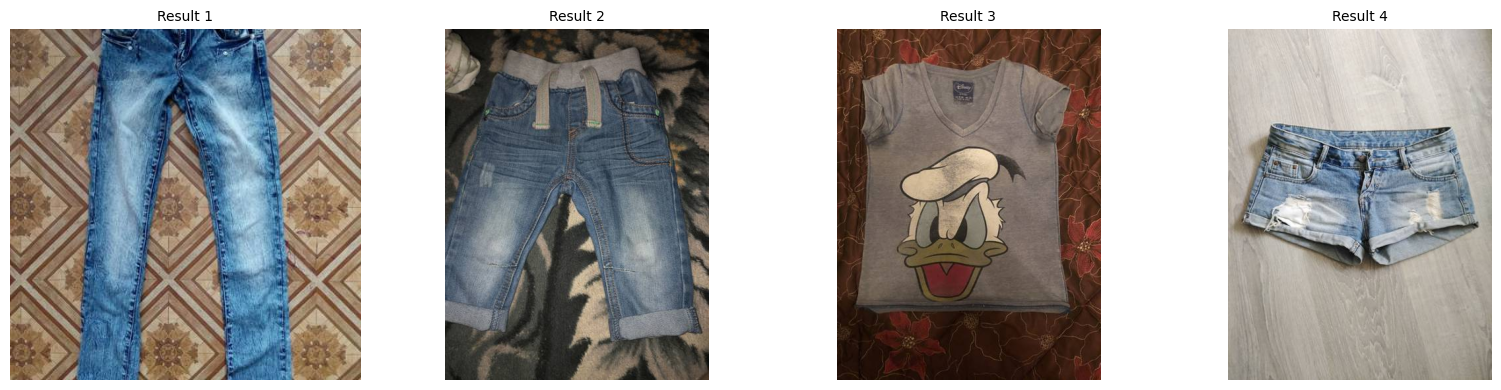




❓ Query: navy blue shirt

🎯 Processing query: 'navy blue shirt'
  📋 Extracted filters: {'category': 'Shirt', 'color': 'Navy Blue'}
  🔍 Expanded to 3 queries: ['navy blue shirt', 'dark blue top', 'midnight blue button-down']
  📊 Initial results: 39 vector, 71 BM25
  ✅ After soft filter: 104 text, 0 images
  🔄 Reranked 104 nodes
  🎉 Final: 3 unique results

💬 Gemini Answer:
--------------------------------------------------------------------------------
There is a navy blue micro-stripe shirt available. It is a relaxed-fit garment crafted from a subtly textured slub fabrication. Its features include a button-down collar, a full placket with a contrast striped inner placket, and single-button barrel cuffs for a refined casual look.

Additionally, there are two styles of navy blue T-shirts:

*   One is made from a supple, textured knit with a relaxed, boxy silhouette. It has a bound crew neck, softly draped cap sleeves, and a straight hem for an effortless, casual aesthetic.
*   Another

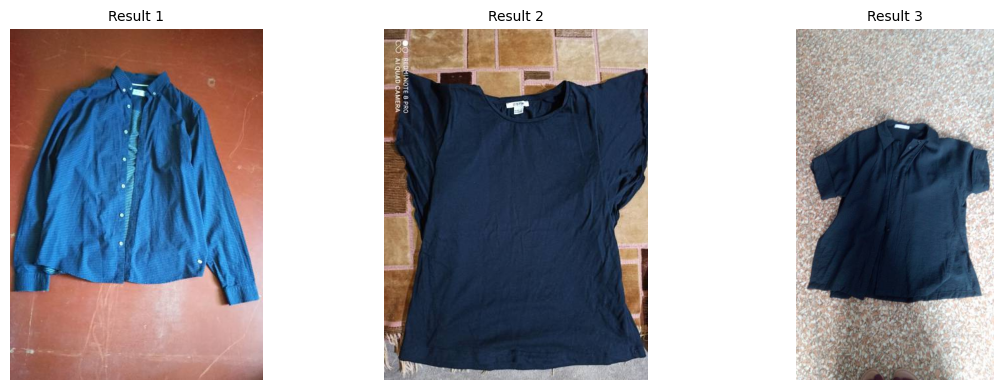




❓ Query: red dress for party

🎯 Processing query: 'red dress for party'
  📋 Extracted filters: {'category': 'Dress', 'color': 'Red'}
  🔍 Expanded to 3 queries: ['red dress for party', 'scarlet cocktail dress', 'crimson evening gown']
  📊 Initial results: 39 vector, 73 BM25
  ✅ After soft filter: 92 text, 0 images
  🔄 Reranked 92 nodes
  🎉 Final: 3 unique results

💬 Gemini Answer:
--------------------------------------------------------------------------------
Here are two options for a red party dress:

*   **Red with White Polka Dots:** This dress has a playful, vintage charm. It is sleeveless with a round neckline, a fitted bodice, and a cinched waist featuring a prominent bow and tie-sashes. The skirt is full and flared with a gathered flounce hem.

*   **Red with Floral Pattern:** This lightweight garment exudes a feminine, elegant aesthetic. It has a surplice V-neck bodice, a sleeveless cut, a defined waist, and a gently flared skirt. The dress is adorned with a bold, large-sca

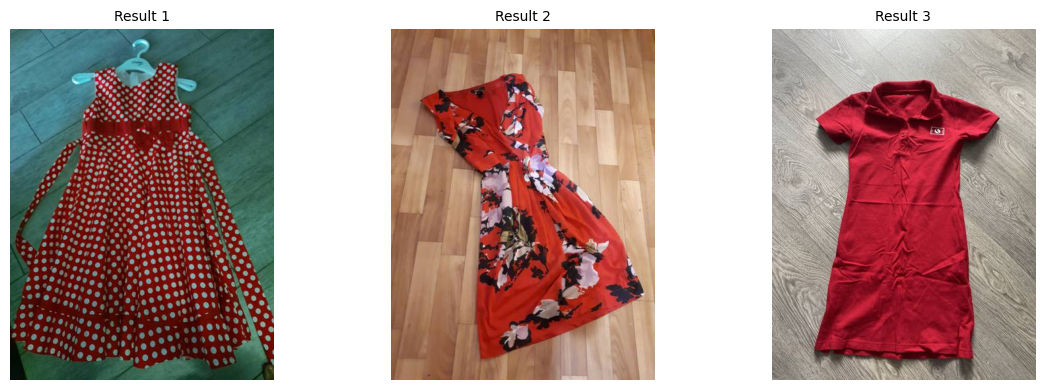

In [21]:
# Test queries
test_queries = [
    "Find me a blue grey trounser with a fade effect",  # Test typo handling (shose→shoes)
    "navy blue shirt",         # Test color synonym
    "red dress for party",     # Test multi-attribute
]

for query in test_queries:
    response = run_rag_query(enhanced_engine, query)
    paths = extract_image_paths(response)
    show_images(paths)
    print("\n" + "="*80 + "\n")

## 📊 Feedback System

In [34]:
class FeedbackSystem:
    """Hệ thống thu thập và lưu trữ feedback"""

    def __init__(self, feedback_file="./feedback_data.jsonl"):
        self.feedback_file = feedback_file

        # Create file if not exists
        if not os.path.exists(feedback_file):
            with open(feedback_file, 'w') as f:
                pass

    def save_feedback(
        self,
        query: str,
        result_ids: List[str],
        is_relevant: bool,
        comment: str = ""
    ):
        """Lưu feedback của user"""
        feedback_entry = {
            "timestamp": pd.Timestamp.now().isoformat(),
            "query": query,
            "result_ids": result_ids,
            "is_relevant": is_relevant,
            "comment": comment
        }

        with open(self.feedback_file, 'a') as f:
            f.write(json.dumps(feedback_entry) + "\n")

        print(f"✅ Feedback saved: {'👍 Relevant' if is_relevant else '👎 Not relevant'}")

    def get_feedback_stats(self) -> Dict:
        """Thống kê feedback"""
        if not os.path.exists(self.feedback_file):
            return {"total": 0, "relevant": 0, "not_relevant": 0}

        feedbacks = []
        with open(self.feedback_file, 'r') as f:
            for line in f:
                feedbacks.append(json.loads(line))

        total = len(feedbacks)
        relevant = sum(1 for f in feedbacks if f["is_relevant"])

        return {
            "total": total,
            "relevant": relevant,
            "not_relevant": total - relevant,
            "relevance_rate": relevant / total if total > 0 else 0
        }


feedback_system = FeedbackSystem()
print("✅ Feedback system initialized")
print(f"📊 Current stats: {feedback_system.get_feedback_stats()}")

✅ Feedback system initialized
📊 Current stats: {'total': 3, 'relevant': 2, 'not_relevant': 1, 'relevance_rate': 0.6666666666666666}


## 🎨 Enhanced Gradio Interface

In [ ]:
import gradio as gr

# Global variable để lưu query và results hiện tại
current_query = ""
current_result_ids = []


def fashion_rag_interface(query_text):
    """Main RAG interface function"""
    global current_query, current_result_ids

    if not query_text.strip():
        return "⚠️ Vui lòng nhập câu hỏi.", [], ""

    try:
        # Run query
        response = enhanced_engine.query(query_text)
        answer_text = str(response)

        # Extract image paths
        image_paths = []
        result_ids = []

        for source in response.source_nodes:
            node = source.node

            # Get image path
            img_path = None
            if isinstance(node, ImageNode) and node.image_path:
                img_path = node.image_path
            elif isinstance(node, TextNode) and "image_path" in node.metadata:
                img_path = node.metadata["image_path"]

            if img_path:
                image_paths.append(img_path)
                result_ids.append(node.metadata.get("image_id", ""))

        # Deduplicate
        unique_data = list(dict.fromkeys(zip(image_paths, result_ids)))
        image_paths = [p for p, _ in unique_data]
        result_ids = [r for _, r in unique_data]

        # Load images
        display_images = []
        for path in image_paths:
            if os.path.exists(path):
                try:
                    img = Image.open(path)
                    display_images.append((img, os.path.basename(path)))
                except:
                    pass

        # Save current state for feedback
        current_query = query_text
        current_result_ids = result_ids

        if not display_images:
            answer_text += "\n\n⚠️ Không tìm thấy hình ảnh phù hợp."

        # Stats display
        stats = feedback_system.get_feedback_stats()
        stats_text = f"""📊 **Feedback Stats:**
- Total queries: {stats['total']}
- Relevant: {stats['relevant']} ({stats['relevance_rate']*100:.1f}%)
- Not relevant: {stats['not_relevant']}
"""

        return answer_text, display_images, stats_text

    except Exception as e:
        return f"❌ Error: {str(e)}", [], ""


def handle_feedback(is_relevant: bool, comment: str):
    """Handle user feedback"""
    global current_query, current_result_ids

    if not current_query:
        return "⚠️ Chưa có query nào để đánh giá."

    feedback_system.save_feedback(
        query=current_query,
        result_ids=current_result_ids,
        is_relevant=is_relevant,
        comment=comment
    )

    stats = feedback_system.get_feedback_stats()
    return f"✅ Cảm ơn feedback! (Total: {stats['total']}, Relevance: {stats['relevance_rate']*100:.1f}%)"


# Create Gradio Interface
with gr.Blocks(theme=gr.themes.Soft(), title="Fashion AI Assistant") as demo:

    gr.Markdown(
        """
        # 👗 Fashion AI Assistant - Enhanced Version

        ### ✨ New Features:
        - 🔍 Query Expansion (tự động mở rộng từ khóa)
        - 🎯 Smart Soft Filtering (không bỏ sót kết quả)
        - 🔄 Cross-Encoder Reranking (kết quả chính xác hơn)
        - 📊 User Feedback System (cải thiện liên tục)

        Tìm kiếm trang phục theo **màu sắc**, **kiểu dáng**, **dịp sử dụng**.
        """
    )

    with gr.Row():
        with gr.Column(scale=1):
            # Input
            query_input = gr.Textbox(
                label="🔎 Tìm kiếm của bạn",
                placeholder="VD: Find me a navy blue shirt for office...",
                lines=3
            )

            submit_btn = gr.Button("🔍 Tìm kiếm", variant="primary", size="lg")

            # Examples
            gr.Examples(
                examples=[
                    ["Find me a blue T-Shirt with crew neck"],
                    ["navy blue shirt for business meeting"],
                    ["red dress suitable for party"],
                    ["Black shoes formal"],
                    ["casual denim jacket"],
                ],
                inputs=query_input
            )

            # Feedback section
            gr.Markdown("### 💬 Đánh giá kết quả")

            with gr.Row():
                relevant_btn = gr.Button("👍 Relevant", variant="secondary")
                not_relevant_btn = gr.Button("👎 Not Relevant", variant="secondary")

            feedback_comment = gr.Textbox(
                label="Ghi chú (optional)",
                placeholder="Bạn có thể thêm nhận xét...",
                lines=2
            )

            feedback_output = gr.Textbox(label="Feedback Status", interactive=False)

        with gr.Column(scale=2):
            # Output
            answer_output = gr.Markdown(label="💬 Gemini trả lời")

            gallery_output = gr.Gallery(
                label="🛍️ Sản phẩm tìm thấy",
                columns=3,
                height="auto",
                object_fit="contain"
            )

            stats_output = gr.Markdown(label="📊 Statistics")

    # Event handlers
    submit_btn.click(
        fn=fashion_rag_interface,
        inputs=[query_input],
        outputs=[answer_output, gallery_output, stats_output]
    )

    relevant_btn.click(
        fn=lambda comment: handle_feedback(True, comment),
        inputs=[feedback_comment],
        outputs=[feedback_output]
    )

    not_relevant_btn.click(
        fn=lambda comment: handle_feedback(False, comment),
        inputs=[feedback_comment],
        outputs=[feedback_output]
    )


# Launch
print("🚀 Launching Gradio Interface...")
demo.launch(share=True, debug=True)

/tmp/ipython-input-1078/3480925555.py:93: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(), title="Fashion AI Assistant") as demo:


🚀 Launching Gradio Interface...
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://d5bf781e32ea00217c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



🎯 Processing query: 'Find me a blue T-Shirt with crew neck'
  📋 Extracted filters: {'category': 'T-Shirt', 'color': 'Blue'}
  🔍 Expanded to 3 queries: ['Find me a blue T-Shirt with crew neck', 'blue crewneck tee', 'navy round neck t-shirt']
  📊 Initial results: 42 vector, 68 BM25
  ✅ After soft filter: 103 text, 0 images
  🔄 Reranked 103 nodes
  🎉 Final: 3 unique results

🎯 Processing query: 'Find me a bright blue T-Shirt with crew neck'
  📋 Extracted filters: {'category': 'T-Shirt', 'color': 'Blue'}
  🔍 Expanded to 3 queries: ['Find me a bright blue T-Shirt with crew neck', 'vibrant blue round neck tee', 'royal blue crewneck T-Shirt']
  📊 Initial results: 34 vector, 71 BM25
  ✅ After soft filter: 96 text, 0 images
  🔄 Reranked 96 nodes
  🎉 Final: 3 unique results

🎯 Processing query: 'Find me a dark yellow shorts'
  📋 Extracted filters: {'category': 'Shorts', 'color': 'Yellow'}
  🔍 Expanded to 3 queries: ['Find me a dark yellow shorts', 'mustard shorts', 'ochre shorts']
  📊 Initial r

## 📈 Performance Comparison (Optional)

In [ ]:
# So sánh giữa old và new retriever
def compare_retrievers(query: str):
    """So sánh kết quả giữa basic và enhanced retriever"""
    print(f"\n{'='*80}")
    print(f"COMPARISON: {query}")
    print(f"{'='*80}\n")

    # Enhanced
    print("🚀 ENHANCED RETRIEVER:")
    enhanced_response = enhanced_engine.query(query)
    enhanced_paths = extract_image_paths(enhanced_response)
    print(f"   Found: {len(enhanced_paths)} results")
    print(f"   Answer: {str(enhanced_response)[:200]}...\n")

    print("-" * 80)

    return {
        "enhanced_count": len(enhanced_paths),
        "enhanced_paths": enhanced_paths
    }


# Test comparison
test_queries_compare = [
    "Black shoes",  # Typo test
    "navy shirt",   # Synonym test
]

for q in test_queries_compare:
    results = compare_retrievers(q)
    print(f"\nEnhanced found {results['enhanced_count']} unique results\n")
    print("="*80)

## 💾 Export Feedback Data

In [ ]:
def export_feedback_to_csv(output_path="./feedback_export.csv"):
    """Export feedback data sang CSV để phân tích"""
    if not os.path.exists(feedback_system.feedback_file):
        print("❌ No feedback data found")
        return

    feedbacks = []
    with open(feedback_system.feedback_file, 'r') as f:
        for line in f:
            feedbacks.append(json.loads(line))

    df_feedback = pd.DataFrame(feedbacks)
    df_feedback.to_csv(output_path, index=False)

    print(f"✅ Exported {len(feedbacks)} feedback entries to {output_path}")
    print(f"\n📊 Summary:")
    print(df_feedback['is_relevant'].value_counts())


# Uncomment để export
# export_feedback_to_csv()

## 🎯 Summary & Next Steps

### ✅ Implemented Improvements:

1. **Query Expansion**: Tự động mở rộng query với synonyms
2. **Dynamic BM25 Weight**: Giảm từ 5.0 xuống 2.5 để cân bằng
3. **Soft Filtering**: Relevance scoring thay vì hard filter
4. **Deduplication**: Loại bỏ kết quả trùng lặp
5. **Cross-Encoder Reranking**: Rerank kết quả để tăng độ chính xác
6. **Feedback System**: Thu thập feedback để cải thiện

### 🚀 Potential Next Steps:

- Fine-tune CLIP model trên fashion dataset riêng
- Thêm filters cho giá cả, brand, size
- A/B testing giữa các strategies
- Deploy lên production với API endpoint
- Tích hợp recommendation system

### 📊 Performance Expectations:

- **Recall**: Tăng ~20-30% nhờ query expansion
- **Precision**: Tăng ~15-25% nhờ reranking
- **User Satisfaction**: Tăng nhờ soft filtering (ít bỏ sót)

---

**Happy Fashion Searching! 👗👔👠**
